In [22]:
import numpy as np
import pandas as pd

files=[
        "../data/raw/Wednesday-workingHours.pcap_ISCX.csv",
        "../data/raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
        "../data/raw/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
        "../data/raw/Tuesday-WorkingHours.pcap_ISCX.csv",
        "../data/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
        "../data/raw/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
        "../data/raw/Friday-WorkingHours-Morning.pcap_ISCX.csv"
    ]

dfs=[]

for file in files:
    temp=pd.read_csv(file)
    temp.columns = temp.columns.str.strip()
    dfs.append(temp)

df=pd.concat(dfs,axis=0,ignore_index=True)

##### Preprocessing

In [23]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

missing_percent = (df.isnull().sum() / len(df)) * 100

df.fillna(df.median(numeric_only=True), inplace=True) #handle missing values

df.drop_duplicates(inplace=True) #remove duplicates

constant_col=df.columns[df.nunique()==1]  #remove constant columns
df.drop(columns=constant_col,inplace=True)

df['Binary_Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1) #binary labeling

df.shape

(2019730, 72)

In [27]:
selected_features = [
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Duration',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'Destination Port',
    'Average Packet Size',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Min Packet Length',
    'Max Packet Length',
    'Fwd Packets/s',
    'Bwd Packets/s'
]

df = df[selected_features + ['Binary_Label']]

df.info()

<class 'pandas.DataFrame'>
Index: 2019730 entries, 0 to 2300824
Data columns (total 20 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Total Fwd Packets            int64  
 1   Total Backward Packets       int64  
 2   Total Length of Fwd Packets  int64  
 3   Total Length of Bwd Packets  int64  
 4   Flow Duration                int64  
 5   Flow Bytes/s                 float64
 6   Flow Packets/s               float64
 7   Packet Length Mean           float64
 8   Packet Length Std            float64
 9   SYN Flag Count               int64  
 10  ACK Flag Count               int64  
 11  Destination Port             int64  
 12  Average Packet Size          float64
 13  Fwd Packet Length Mean       float64
 14  Bwd Packet Length Mean       float64
 15  Min Packet Length            int64  
 16  Max Packet Length            int64  
 17  Fwd Packets/s                float64
 18  Bwd Packets/s                float64
 19  Binary_Label    

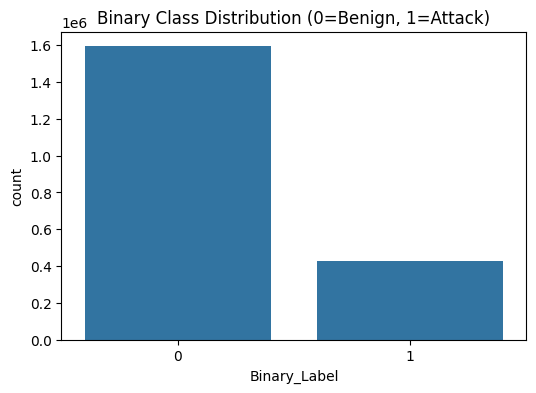

Binary_Label
0    78.914112
1    21.085888
Name: proportion, dtype: float64


In [28]:
X = df.drop(['Binary_Label'], axis=1)  #input output split
y = df["Binary_Label"]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Binary Class Distribution (0=Benign, 1=Attack)")
plt.show()

print(y.value_counts(normalize=True)*100)

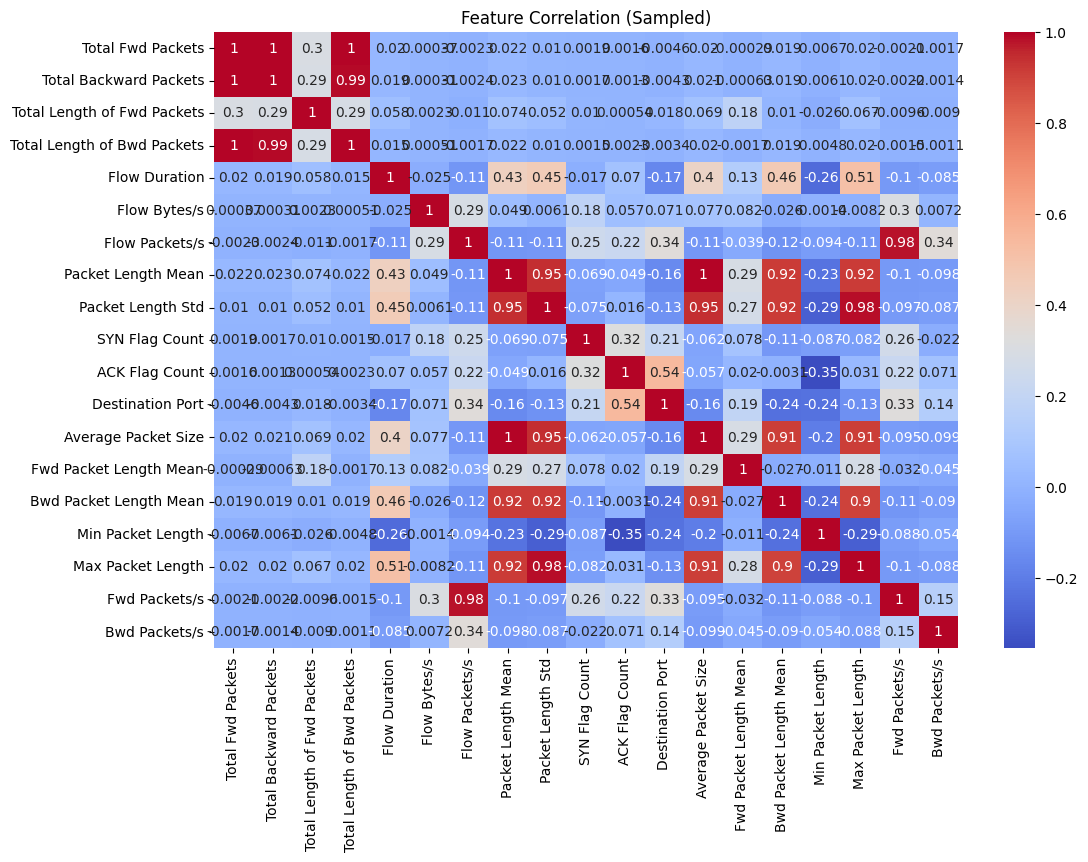

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation (Sampled)")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(  #train test split
    X, y, test_size=0.2, random_state=42, stratify=y
)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)  #Applying smote to handle class imbalance
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train.value_counts())

After SMOTE: Binary_Label
0    1275082
1    1275082
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)  #train
y_pred = model.predict(X_test)  #test
classification_report(y_test, y_pred)  #evaluation

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    318770
           1       0.99      0.99      0.99     85176

    accuracy                           1.00    403946
   macro avg       0.99      0.99      0.99    403946
weighted avg       1.00      1.00      1.00    403946



Packet Length Std              0.154219
Average Packet Size            0.143723
Bwd Packet Length Mean         0.135806
Max Packet Length              0.129079
Destination Port               0.093237
Packet Length Mean             0.069776
Total Length of Bwd Packets    0.067413
Fwd Packet Length Mean         0.061028
Total Length of Fwd Packets    0.051147
Total Fwd Packets              0.039883
Total Backward Packets         0.033821
Min Packet Length              0.020867
dtype: float64


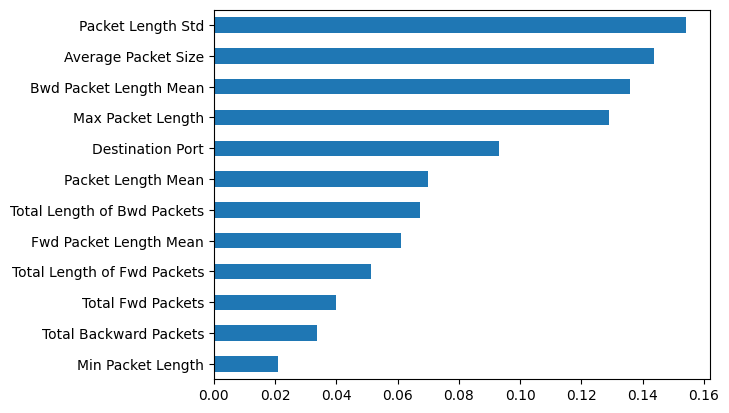

(2019730, 12)

In [60]:
feature_names = X_train.columns
importance = model.feature_importances_

feat_imp = pd.Series(importance, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp)

top_features = feat_imp.head(12).index.tolist()

feat_imp.head(12).plot(kind='barh')
plt.gca().invert_yaxis()
plt.show()

X = df[top_features]
y = df["Binary_Label"]

X.shape

In [63]:
# Split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE again
X_train, y_train = smote.fit_resample(X_train, y_train)

# Train again
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

from sklearn.metrics import recall_score
print("Recall (Attack detection):", recall_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    318770
           1       0.96      0.99      0.98     85176

    accuracy                           0.99    403946
   macro avg       0.98      0.99      0.99    403946
weighted avg       0.99      0.99      0.99    403946

Recall (Attack detection): 0.9930731661500892


#### Anomaly Detection

In [56]:
from sklearn.ensemble import IsolationForest

X_benign = X[y == 0]

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

iso_model.fit(X_benign)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [57]:
preds = iso_model.predict(X_test)

print(pd.Series(preds).value_counts())

 1    322169
-1     81777
Name: count, dtype: int64


In [58]:
def hybrid_predict(sample):

    iso_pred = iso_model.predict(sample)[0]
    clf_pred = model.predict(sample)[0]

    # If classifier strongly says attack → trust it
    if clf_pred == 1:
        return "Known Attack"

    # Then anomaly
    if iso_pred == -1:
        return "Unknown Attack"

    return "Normal Traffic"

#### Testing

In [59]:
for i in range(20):
    sample = X_test.iloc[i:i+1]

    result = hybrid_predict(sample)

    actual = y_test.iloc[i]

    print(f"Index {i} → Predicted: {result} | Actual: {actual}")

Index 0 → Predicted: Known Attack | Actual: 1
Index 1 → Predicted: Normal Traffic | Actual: 0
Index 2 → Predicted: Normal Traffic | Actual: 0
Index 3 → Predicted: Normal Traffic | Actual: 0
Index 4 → Predicted: Normal Traffic | Actual: 0
Index 5 → Predicted: Normal Traffic | Actual: 0
Index 6 → Predicted: Normal Traffic | Actual: 0
Index 7 → Predicted: Normal Traffic | Actual: 0
Index 8 → Predicted: Normal Traffic | Actual: 0
Index 9 → Predicted: Normal Traffic | Actual: 0
Index 10 → Predicted: Normal Traffic | Actual: 0
Index 11 → Predicted: Normal Traffic | Actual: 0
Index 12 → Predicted: Known Attack | Actual: 1
Index 13 → Predicted: Normal Traffic | Actual: 0
Index 14 → Predicted: Known Attack | Actual: 1
Index 15 → Predicted: Normal Traffic | Actual: 0
Index 16 → Predicted: Normal Traffic | Actual: 0
Index 17 → Predicted: Known Attack | Actual: 1
Index 18 → Predicted: Normal Traffic | Actual: 0
Index 19 → Predicted: Normal Traffic | Actual: 0


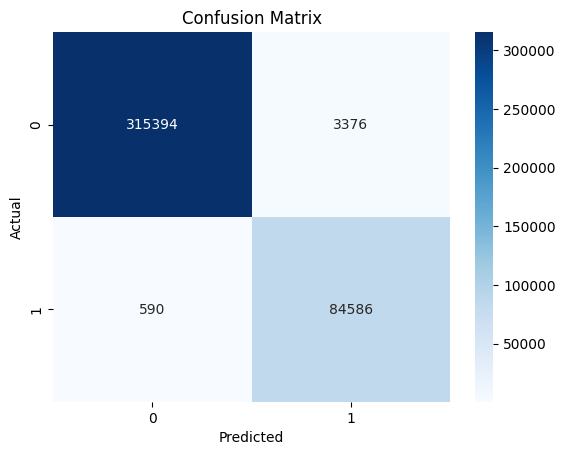

In [61]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

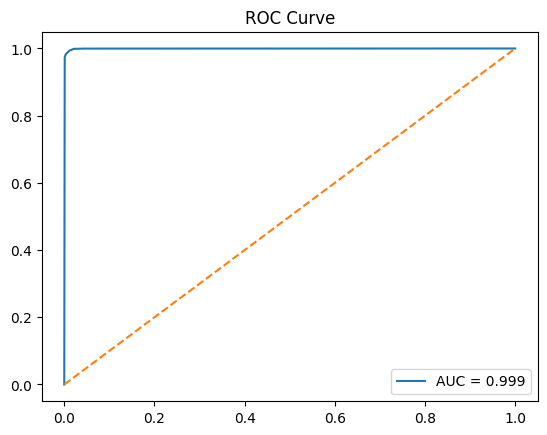

In [62]:
from sklearn.metrics import roc_curve, auc

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [66]:
import joblib

joblib.dump(model, "../models/rf_model.pkl")
joblib.dump(iso_model, "../models/iso_model.pkl")
joblib.dump(top_features, "../models/features.pkl")

['../models/features.pkl']